# Exercises  "Lecture 13: Clustering"

In this set of exercises, we will use clustering to group the wikipedia articles into 16 clusters. Since we are working on clustering (unsupervised machine learning),  we will ignore the labels (the category of the article) when training. We will use them however to evaluate the trained model (intrinsic evaluation).


The exercises cover the following points:

* Storing the data into a pandas dataframe and inspecting the data
* Learning a clustering model from the data 
* Inspecting the output clusters

Data: wkp_sorted.zip      

Python libraries
- sklearn.datasets to load data 
- pandas
- numpy unique method to remove duplicate   

Cheat sheets
- CS_clustering.ipynb


##  Loading the Data into a Dataframe

**Exercise 1** 

* Create a pandas dataframe containing two columns one for the text and one for the category of each Wikipedia article included in  "wkp_sorted/". 
* Use sklearn.datasets load_files method (cf. **clustering CS**) 

In [2]:
import pandas as pd
from sklearn.datasets import load_files

In [10]:
data

{'data': ['The Cardiff Roller Collective (CRoC) are a roller sports league based in Cardiff, Wales.  Founded in 2010, the league has three roller derby, one roller hockey team, and an artistic skating group.\nFounded in October 2010,  It initially had two teams, the Raiders of Roath Park and the Roathmantics; these were subsequently rearranged.  The Collective was also joined by the Bridgend Bombshells, which had been founded in 2009.  The Bombshells were based at the Bridgend Recreation Centre, in a town near Cardiff, although this was set for closure at the end of 2011.By late 2011, CRoC had launched roller hockey and artistic roller skating groups, and its membership exceeded seventy people.CRoC became members of the United Kingdom Roller Derby Association in May 2012.\n\n\n== References ==\n',
  '"Go! Pack Go!" is the fight song of the Green Bay Packers, and the first for a professional American football team. It was written by Eric Karll, a commercial jingle writer in Milwaukee, a

In [ ]:
DATA_DIR = "wkp_sorted/"
data = load_files(DATA_DIR, encoding="utf-8", decode_error="replace")
# df = pd.DataFrame(list(zip(data['data'], data['target_names'])), columns=['text', 'label'])
# df.head()

,text,label
0,The Cardiff Roller Collective (CRoC) are a rol...,Airports
1,"""Go! Pack Go!"" is the fight song of the Green ...",Artists
2,Al-Machriq (English translation: The East) was...,Astronauts
3,Ajman International Airport (Arabic: مطار عجما...,Astronomical_objects
4,Kapla is a construction set for children and a...,Building


In [22]:
# Create a DataFrame
df = pd.DataFrame({
    'text': data['data'], 
    'label': [data['target_names'][label] for label in data['target']]
})

In [25]:
df.head()

,text,label
0,The Cardiff Roller Collective (CRoC) are a rol...,Sports_teams
1,"""Go! Pack Go!"" is the fight song of the Green ...",Sports_teams
2,Al-Machriq (English translation: The East) was...,Universities_and_colleges
3,Ajman International Airport (Arabic: مطار عجما...,Airports
4,Kapla is a construction set for children and a...,Building


**Exercise 2**  

* Add a new column to your dataframe with header "Headers" in which you include the headers extracted from the texts
* Use the code you developed in Exercise 3 of 10_Exercise_sheet_stats.ipynb

In [26]:
import re

def get_title(text):
    pattern = r"^==\s*(.*?)\s*==$"  # Matches '== Header ==' with optional spaces
    return re.findall(pattern, text, re.MULTILINE)

df['Headers'] = df['text'].apply(get_title)

In [27]:
df.tail()

,text,label,Headers
155,Memphis Air Route Traffic Control Center (ZME)...,Airports,"[Breakdown of airspace, References, External l..."
156,Al-Haj Suliman Yari (19 August 1936 – 10 May 2...,Politicians,[References]
157,Sapphire Stagg is a fictional character appear...,Comics_characters,"[Fictional character biography, = Birds of Pre..."
158,Relocation of professional sports teams occurs...,Sports_teams,"[Association football, Baseball, Basketball, R..."
159,"In aerodynamics, pitch-up is an uncommanded no...",Building,"[History, Description, Mitigation, Sabre dance..."


**Exercise 3** 

* How many articles are there ? Use the dataframe shape attribute which outputs the shape (nb of rows and columns) of a dataframe.

Expected answer: (160,2) 

In [28]:
df.shape

(160, 3)

**Exercise 4** 

* How many labels (categories) are there ?
* Use numpy unique method (cf. numpy CS)

Expected answer: 16

In [33]:
set(data['target']).__len__()

16

**Exercise 5** 

* How many articles per category ?
* Use pandas 'groupby' and 'size' methods (cf. Pandas CS)

In [37]:
df.groupby('label').size().reset_index(name='count')

,label,count
0,Airports,10
1,Artists,10
2,Astronauts,10
3,Astronomical_objects,10
4,Building,10
5,City,10
6,Comics_characters,10
7,Companies,10
8,Foods,10
9,Monuments_and_memorials,10


**Exercise 6** 

* Don't forget to shuffle the data (Cf. pandas CS)

In [41]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

## Vectorizing the input texts

$Y$ = the categories (Astronaut, etc.) we are aiming to rediscover. These are **not** used for clustering but they will be used for evaluation

$X$ = the features used for clustering. The features of Wikipedia article is the list of tokens contained in that item. We hope that words can help group the articles into 16 clusters matching the Wikipedia categories.


**Exercise 7** 

* Vectorize the input (X)
* Use sklearn [TfidfVectorizer]( https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) method to turn the Wikipedia articles into a TF-IDF matrix where each row represents a news item, the columns are tokens and the cell contains the tf-idf score of each token.

Three steps
* Import the TfidfVectorizer method from sklearn
* Create a tf-idf vectorizer. The maximum nb of features should be set to 500. Set use_idf to True and stop_words to "english".
* Apply the tfidf_vectorizer.fit_transform method to X to vectorize all input texts

In [43]:
X_raw = df.text.tolist()
y = df.label.tolist()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X_raw)
print(X.shape)

(160, 19069)


**Exercise 8** 

* Print out the features created by the vectorizer (use the get_feature_names() method).

Expected answer: a list of tokens

In [49]:
vectorizer.get_feature_names_out()[-100:]

array(['ōjin', 'ōtaki', 'śląski', 'şükrü', 'şəki', 'şəkidə', 'štúr',
       'židlochovice', 'ɓaleeɓe', 'ərdoğana', 'ɪtsɛ', 'ˈmərðin', 'ˈsmɪr',
       'ˈsɑʋonˌlinːɑ', 'ˈvocɪtsɛ', 'ˈɑkɕəselˌskɛˀp', 'ˈʒɪdloxovɪtsɛ',
       'βρυώνης', 'ομέρ', 'ад', 'аеродроми', 'акмаль', 'акционерно',
       'александрович', 'ахмет', 'виктор', 'владимир', 'джанибеков',
       'дружество', 'иванович', 'икрамов', 'икрамович', 'ильин',
       'криштоп', 'крысин', 'нухаев', 'ольга', 'србије', 'таштамирович',
       'хож', 'המשמר', 'יד', 'על', 'أردو', 'اردو', 'البديل', 'البيرق',
       'التلميذ', 'الثورة', 'الجزيرة', 'الجزیرہ', 'الجماهير', 'الحركة',
       'الدولي', 'الديمقراطية', 'الزقورة', 'العرب', 'الفضل', 'الم',
       'الملايين', 'الوسط', 'الوطنى', 'برج', 'حدتو', 'خير', 'عجمان',
       'علاء', 'قصر', 'للتحرر', 'مباشر', 'مصر', 'مطار', '光と其諧調', '古道',
       '吉川富夫', '大道', '帝道', '惟神の道', '日本の写真家', '昭和来観', '林丹', '林丹全国球迷会',
       '正四位', '牛肉泡饃', '牛肉泡馍', '神ながらの道', '神の道', '神道', '羊肉泡饃', '羊肉泡馍',
       '聂天翔', '聂捷琳', 

##  Training a K-means clustering model

**Exercise 9**

* Create a K-means object (import KMeans from sklearn.cluster). 
* Set the number of clusters to 16
* Train this object on the tf-idf matrix you created from the data (use the kmeans fit method)

In [50]:
from sklearn.cluster import KMeans

In [ ]:
kmeans = KMeans(n_clusters=16, random_state=0, n_init="auto").fit(X)
kmeans.labels_

array([14,  2,  4,  2,  7, 14,  2, 14, 14,  7,  2,  2,  2,  2,  8,  7, 14,
        8,  1,  2,  2,  2,  0,  2,  0,  2, 14,  7,  2, 14,  2,  2,  2,  2,
        7,  2, 15,  2, 12,  7, 15,  2,  2, 12,  7, 13, 12,  2, 12,  1,  2,
        2,  2, 10,  2,  2,  2,  2,  3, 12,  2,  2,  2,  8,  2,  6,  2,  2,
        2,  1,  1,  3,  6,  1,  7,  2,  2,  2,  8,  2, 12,  2,  2, 12,  2,
        9,  8,  0,  2,  2,  9,  2,  2,  2,  2,  2,  1,  2,  5,  2,  2, 14,
        7,  2,  7,  7,  2,  2, 12, 11,  2, 14,  2, 14,  2,  2,  2,  7,  3,
        2,  2, 15,  2,  2,  3,  2,  2, 12,  7,  9, 14,  2,  2,  2,  2,  2,
        1,  7,  2, 14, 12,  2,  2,  2,  2,  2,  2,  2,  2,  3,  2,  2,  5,
        2,  2,  2,  5,  2, 13,  2], dtype=int32)

In [52]:
kmeans.cluster_centers_

array([[0.        , 0.00831778, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.01199213, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.00050853, 0.00514778, 0.00085601, ..., 0.00072167, 0.        ,
        0.        ],
       ...,
       [0.        , 0.03048332, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.00250584,
        0.00501168],
       [0.        , 0.0061091 , 0.        , ..., 0.        , 0.        ,
        0.        ]])

## Inspecting Clustering Results

**Exercise 10** 

* Create a dataframe aligning the clustering results with the news items and their category
* The dataframe should contains 3 columns with headers "Text", "Category" and "Cluster"
* Extract the texts and labels from the dataframe you created from the wikipedia files
* Extract the list of cluster labels produced for each input text by the clustering algorithm (km.labels_)
* Create the required dataframe using these information 

In [55]:
newdf = {'Text':X_raw,'Category':y,'Cluster':kmeans.labels_}
newdf = pd.DataFrame(newdf)
newdf.head()

,Text,Category,Cluster
0,Akmyrat Rejepow is a Turkmen general and gover...,Politicians,14
1,Anti-shock body is the name given by Richard T...,Building,2
2,Al Jazeera International Documentary Film Fest...,Companies,4
3,Cloghanmore is a megalithic chamber tomb of th...,Monuments_and_memorials,2
4,"Al Jazeera Urdu (Arabic: الجزيرة أردو, Urdu: ا...",Companies,7


In [129]:
newdf.groupby(['Cluster', 'Category',]).count()

Text
Cluster Category                       
0       Astronauts                    3
1       Foods                         1
        Sports_teams                  5
        Sportspeople                  1
2       Airports                      3
        Artists                       5
        Astronauts                    3
        Astronomical_objects          2
        Building                     10
        City                         10
        Comics_characters             7
        Companies                     3
        Foods                         9
        Monuments_and_memorials      10
        Politicians                   6
        Sports_teams                  5
        Sportspeople                  5
        Transport                     5
        Universities_and_colleges     1
        Written_communication         4
3       Airports                      5
4       Companies                     1
5       Astronomical_objects          3
6       Universities_and_colleges     2
7       Artists                       1
        Companies                     6
        Transport                     1
        Universities_and_colleges     1
        Written_communication         5
8       Astronomical_objects          5
9       Airports                      1
        Universities_and_colleges     2
10      Artists                       1
11      Comics_characters             1
12      Astronauts                    3
        Comics_characters             1
        Politicians                   1
        Sportspeople                  1
        Transport                     3
        Written_communication         1
13      Airports                      1
        Transport                     1
14      Artists                       3
        Astronauts                    1
        Comics_characters             1
        Politicians                   3
        Sportspeople                  3
        Universities_and_colleges     1
15      Universities_and_colleges     3

In [128]:
newdf.groupby(['Category', 'Cluster']).count()

Text
Category                  Cluster      
Airports                  2           3
                          3           5
                          9           1
                          13          1
Artists                   2           5
                          7           1
                          10          1
                          14          3
Astronauts                0           3
                          2           3
                          12          3
                          14          1
Astronomical_objects      2           2
                          5           3
                          8           5
Building                  2          10
City                      2          10
Comics_characters         2           7
                          11          1
                          12          1
                          14          1
Companies                 2           3
                          4           1
                          7           6
Foods                     1           1
                          2           9
Monuments_and_memorials   2          10
Politicians               2           6
                          12          1
                          14          3
Sports_teams              1           5
                          2           5
Sportspeople              1           1
                          2           5
                          12          1
                          14          3
Transport                 2           5
                          7           1
                          12          3
                          13          1
Universities_and_colleges 2           1
                          6           2
                          7           1
                          9           2
                          14          1
                          15          3
Written_communication     2           4
                          7           5
                          12          1

**Exercise 11** 

* Print out the number of items per clusters
* use pandas value_counts() method

In [57]:
newdf['Cluster'].value_counts()

Cluster
2     88
7     14
14    12
12    10
1      7
8      5
3      5
0      3
5      3
15     3
9      3
6      2
13     2
4      1
10     1
11     1
Name: count, dtype: int64

**Exercise 12** 

* Evaluate the clusters
* Import metrics from sklearns and compute homogeneity, completeness, v_measure, adjusted rand index and silhouette coefficient
* Print each score out

This should yield something like the following

Homogeneity: 0.207
Completeness: 0.283
V-measure: 0.239
Adjusted Rand-Index: -0.000
Silhouette Coefficient: 0.379


In [59]:
from sklearn import metrics
# Compute and show evaluation scores
# When a ground truth is available
print("Homogeneity: %0.3f" % metrics.homogeneity_score(y, kmeans.labels_))
print("Completeness: %0.3f" % metrics.completeness_score(y, kmeans.labels_))
print("V-measure: %0.3f" % metrics.v_measure_score(y, kmeans.labels_))
print("Adjusted Rand-Index: %.3f"
      % metrics.adjusted_rand_score(y, kmeans.labels_))
# When no ground truth is available
print("Silhouette Coefficient: %0.3f"
     % metrics.silhouette_score(X, kmeans.labels_, sample_size=1000))
print()

Homogeneity: 0.335
Completeness: 0.525
V-measure: 0.409
Adjusted Rand-Index: 0.052
Silhouette Coefficient: 0.021



**Exercise 13**  

* Print out the top 50 words of each cluster 

Your output should be something like that:

Top terms per cluster:
Cluster 0: references television film notes achievements characterization liability legend historical airports people personal background winners podcasts railair publication properties programs courses exhibitions production filmography architecture miscellaneous advantages plot afl ribbons nrl retired preparation cast baseball basketball subaltern impact uses variations fleet badges vision runaways tenure trial gubernatorial elections conviction execution 52 animation portraits writing regenesis origin novels death hybrid locations memorialization australia athletics founders partnerships academics organization canada history career facilities access security operations cargo passengers regulation location bangladesh iraq antisemitism kuwait syria sudan tunisia libya somalia bahrain algeria malaysia egypt spain india israel categorization 2007 citations 2009 2011 chronology contributors

Cluster 1: references writing controversy doubles distance design description demographics definition death courses cosmogony conviction contributors blazon citations chronology characterization categorization cast cargo career canada brazil economy education egypt elections hybrid honors history historical gubernatorial geography gallery france founders fleet finland filmography film festivals features family facilities exhibitions execution etymology entertainment books biography impact bibliography aftermath afl advantages achievements access academics 52 2018 2017 2016 2015 2014 2013 2012 2011 2010 2009 2008 2007 2006 2005 airports algeria alternatives australia beliefs ba

In [74]:
from sklearn.feature_extraction.text import CountVectorizer
from copy import deepcopy

In [72]:
cluster_n = sorted(newdf['Cluster'].unique())

In [118]:
d = {}
for c in cluster_n:
    # Step 1: Create a CountVectorizer instance
    vectorizer = CountVectorizer(stop_words='english')
    temp = deepcopy(newdf[newdf['Cluster'] == c])

    # Step 2: Fit and transform the documents
    X = vectorizer.fit_transform(temp.Text)

    # Step 3: Convert the result to a DataFrame for easier manipulation
    df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

    # Step 4: Sum the counts for each term across all documents
    term_counts = df.sum().sort_values(ascending=False)

    # Step 5: Get the top 50 terms
    top_50_terms = term_counts.head(50)
    # d[c] = list(top_50_terms.index.to_list())
    d[c] = [list(top_50_terms.index.to_list()), top_50_terms.values]

In [124]:
for key in d.keys():
    print(f"Cluster {key}:\n{', '.join(d[key][0])}")

Cluster 0:
space, dyson, caldwell, nasa, flight, mission, award, air, astronaut, university, shuttle, force, washington, sts, medal, crew, international, california, station, research, state, training, june, 2010, expedition, service, fabian, august, american, science, graduate, environmental, 24, hours, second, 17, iss, engineering, assigned, school, served, 1996, base, worked, russian, satellite, born, chemistry, society, aeronautics
Cluster 1:
club, moved, stadium, football, league, home, team, played, season, new, games, ground, year, melbourne, game, based, oval, sports, city, founded, colorado, shanghai, 000, 2007, coast, sydney, brisbane, play, 2011, park, teams, afl, playing, gold, clubs, changed, 2009, headquarters, national, renamed, north, hohhot, administration, 2004, 2005, shenyang, 2012, centre, professional, 2000
Cluster 2:
airspace, shinto, people, kami, new, aircraft, known, time, merlin, lin, hogarth, fauré, used, world, theatre, use, men, burial, area, wing, later, c

## Visualizing  clusters.

Provided


In [60]:
import os  # for os.path.basename

import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import MDS

dist = 1 - cosine_similarity(X)

# Use multidimensional scaling to convert the dist matrix into a 2-dimensional array 

MDS()

# n_components=2 to plot results in a two-dimensional plane
# "precomputed" because the  distance matrix dist is already computed
# `random_state` set to 1 so that the plot is reproducible.
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=1)

pos = mds.fit_transform(dist)  # shape (n_components, n_samples)

xs, ys = pos[:, 0], pos[:, 1]

In [61]:
#set up colors per clusters using a dict
# #1b9e77 (green) #d95f02 (orange) #7570b3 (purple) #e7298a (pink)
cluster_colors = {0: '#f0140c', 1: '#ad7144', 2: '#f5b92f', 3: '#e8f007', 4: '#88e014', \
                  5:"#0eedb2", 6:"#0dafdb", \
                  7:"#1330ed", 8:"#9a09e8", 9:"#e605b1", 10:"#c4a29d", 11:"#695232", 12:"#f7f088", 13:"#7e8778", \
                  14:"#7dada2", 15:"#628cf5"}

#set up cluster names using a dict
#cluster_names = {0: 'techno'}


In [64]:
dict(x=xs, y=ys)

{'x': array([-0.54944779, -0.45140326, -0.01838449, -0.52775389,  0.03950102,
        -0.25214007,  0.58386349,  0.57822819, -0.06301231,  0.041615  ,
         0.34096919, -0.55069804, -0.72316119,  0.32687657,  0.16950042,
         0.76818738, -0.1031364 ,  0.36049293, -0.25271413,  0.17962661,
         0.32831977,  0.55275562, -0.21165182,  0.11229765, -0.08984459,
        -0.65327825,  0.65818986, -0.47912322, -0.31906774,  0.03510106,
        -0.1481328 ,  0.0730621 , -0.55993078,  0.36097277, -0.64507474,
         0.00810439, -0.5294976 ,  0.17637986,  0.51584958,  0.34000657,
        -0.03039182,  0.246297  ,  0.01418855,  0.28808482,  0.43381507,
         0.05081421,  0.56999673,  0.63481483,  0.40239974,  0.4516795 ,
         0.25556405, -0.03201146, -0.32181947,  0.80034881, -0.47033365,
        -0.02075667,  0.53074235,  0.00234437, -0.25958592, -0.07871247,
        -0.34292086, -0.3420037 , -0.67632229, -0.22560893,  0.2519039 ,
         0.63330264,  0.57797163,  0.21482493,

/tmp/ipykernel_93041/795663848.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(numpoints=1)  #show legend with only 1 point


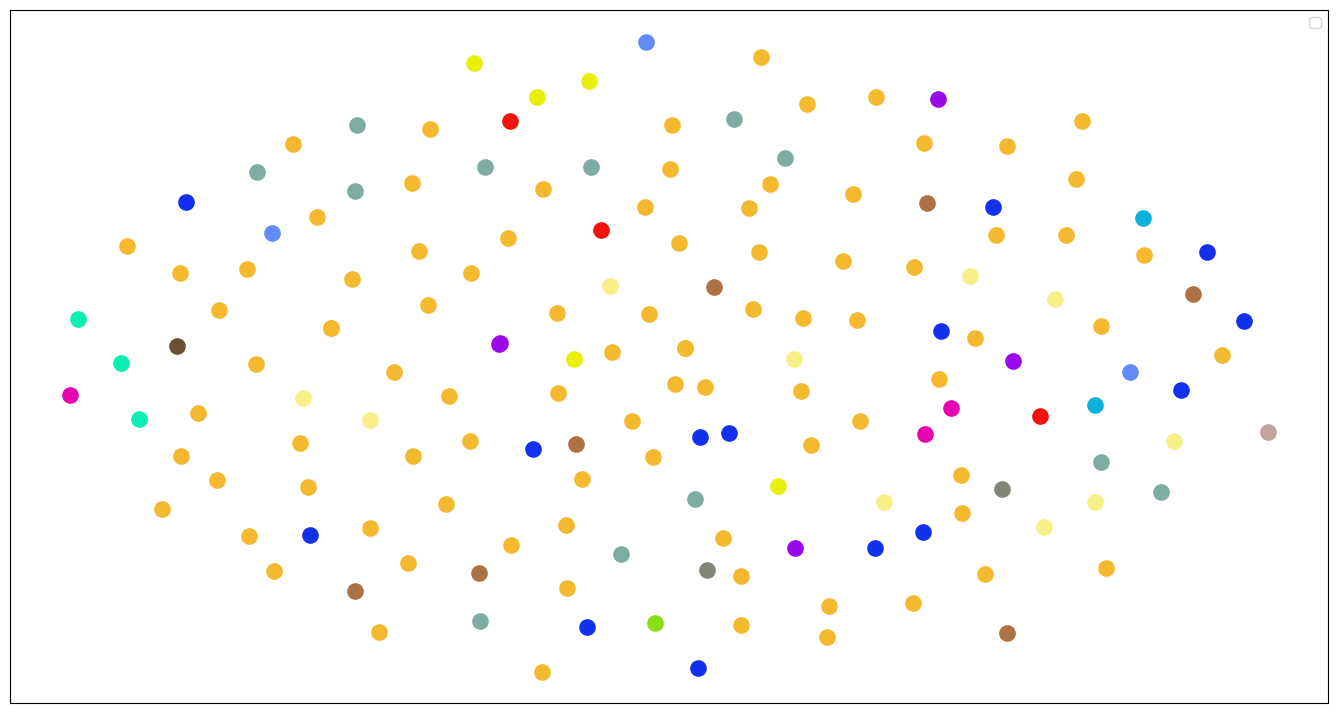

In [125]:
#some ipython magic to show the matplotlib plots inline
%matplotlib inline 

#create data frame that has the result of the MDS plus the cluster numbers and titles
df = pd.DataFrame(dict(x=xs, y=ys, label=kmeans.labels_))

#group by cluster
groups = df.groupby('label')

# set up plot
fig, ax = plt.subplots(figsize=(17, 9)) # set size
ax.margins(0.05) # Optional, just adds 5% padding to the autoscaling

#iterate through groups to layer the plot
#note that I use the cluster_name and cluster_color dicts with the 'name' lookup to return the appropriate color/label
for name, group in groups:
    ax.plot(group.x, group.y, marker='o', linestyle='', ms=12, 
        #    label=cluster_names[name], 
            color=cluster_colors[name], 
            mec='none')
    ax.set_aspect('auto')
    ax.tick_params(\
        axis= 'x',          # changes apply to the x-axis
        which='both',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=False,         # ticks along the top edge are off
        labelbottom=False)
    ax.tick_params(\
        axis= 'y',         # changes apply to the y-axis
        which='both',      # both major and minor ticks are affected
        left=False,      # ticks along the bottom edge are off
        top=False,         # ticks along the top edge are off
        labelleft=False)
    
ax.legend(numpoints=1)  #show legend with only 1 point
    
    
plt.show() #show the plot
